In [5]:
import scipy.io
import numpy as np
import pandas as pd
from pathlib import Path
import gymnasium as gym
from gymnasium import spaces
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from stable_baselines3.common.env_checker import check_env
print("INFO: Import Library")

INFO: Import Library


# Load Dataset

In [6]:
def load_mat_file(file_path):
    path =Path(file_path)
    try:
        mat = scipy.io.loadmat(path)
        if 'meas' not in mat:
            print(f"ERROR: Key 'meas' is not found in {path.name}")
            return None
        
        data_struct = mat["meas"][0,0]
        names = data_struct.dtype.names
        raw_data = {}
        for name in names:
            content = data_struct[name].flatten()
            
            if len(content) > 0 and isinstance(content[0], np.ndarray):
                raw_data[name] = content[0].flatten()
            else:
                raw_data[name] = content
            
        lengths = [len(v) for v in raw_data.values() if isinstance(v, (np.ndarray, list))]
        max_len = max(lengths) if lengths else 1

        final_data = {}
        for name, values in raw_data.items():
            curr_len = len(values) if isinstance(values, (np.ndarray, list)) else 1
            
            if curr_len != max_len:
                single_val = values[0] if curr_len > 0 else np.nan
                if hasattr(single_val, 'decode'):
                    single_val = single_val.decode('utf-8')
                final_data[name] = [single_val] * max_len
            else:
                if isinstance(values, np.ndarray) and values.dtype.kind in ['S', 'V']:
                    final_data[name] = [v.decode('utf-8') if hasattr(v, 'decode') else v for v in values]
                else:
                    final_data[name] = values

        df = pd.DataFrame(final_data)
        return df


    except Exception as e:
        print(f"ERROR: Failed to load {path.name}. {e}")

In [7]:
import pandas as pd
from pathlib import Path

base_path = Path('datasets/1-Open Data')

all_dfs = []

for file_path in base_path.rglob('*.mat'):
    try:
        print(f'INFO: System is processing to load {file_path}')
        df_temp = load_mat_file(str(file_path))
        
        df_temp['Session_ID'] = file_path 
        df_temp['SOC_lag_1'] = df_temp['SOC'].shift(1)
        df_temp = df_temp.dropna(subset=['SOC_lag_1'])
        
        all_dfs.append(df_temp)
        print(f"INFO: Success to load {file_path}")
        
    except Exception as e:
        print(f"ERROR: Failed to load {file_path}: {e}")

df_master = pd.concat(all_dfs, ignore_index=True)
df_master = df_master.drop(columns=[
    'TimeStamp', 
    'Time', 
    'Battery_Temp_degC', 
    'Ambient_Temp_degC', 
    'Cycle_Label', 
    'Test_Cell', 
    # 'Session_ID'
    ])

INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_charge_05-16-21_06.54 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_

In [8]:
# df_master = load_mat_file('datasets/1-Open Data/m80/-10C/Characterization Tests/1_Other_10-23-21_17.55 Tesla_Char_-10C_V3_Channel_1_Wb_1.mat')
# df_master['Session_ID'] = 'datasets/1-Open Data/m80/-10C/Characterization Tests/1_Other_10-23-21_17.55 Tesla_Char_-10C_V3_Channel_1_Wb_1.mat'
# df_master = df_master.drop(columns=[
#     'TimeStamp', 
#     'Time', 
#     'Battery_Temp_degC', 
#     'Ambient_Temp_degC', 
#     'Cycle_Label', 
#     'Test_Cell', 
#     # 'Session_ID'
#     ])

In [9]:
df_master

,Voltage,Current,Ah,SOC,Power,Wh,Session_ID,SOC_lag_1
0,4.181289,0.0,0.0,1.0,0.0,0.00000,datasets/1-Open Data/m1000/40C/Drive Cycles/20...,1.0
1,4.181289,0.0,0.0,1.0,0.0,0.00000,datasets/1-Open Data/m1000/40C/Drive Cycles/20...,1.0
2,4.181289,0.0,0.0,1.0,0.0,0.00000,datasets/1-Open Data/m1000/40C/Drive Cycles/20...,1.0
3,4.181289,0.0,0.0,1.0,0.0,0.00000,datasets/1-Open Data/m1000/40C/Drive Cycles/20...,1.0
4,4.181289,0.0,0.0,1.0,0.0,0.00000,datasets/1-Open Data/m1000/40C/Drive Cycles/20...,1.0
...,...,...,...,...,...,...,...,...
24414243,4.181655,0.0,0.0,1.0,0.0,-0.17619,datasets/1-Open Data/m80/25C/Characterization ...,1.0
24414244,4.181645,0.0,0.0,1.0,0.0,-0.17619,datasets/1-Open Data/m80/25C/Characterization ...,1.0
24414245,4.181600,0.0,0.0,1.0,0.0,-0.17619,datasets/1-Open Data/m80/25C/Characterization ...,1.0
24414246,4.181600,0.0,0.0,1.0,0.0,-0.17619,datasets/1-Open Data/m80/25C/Characterization ...,1.0


# Reinforcement Learning

In [10]:
features = ['Voltage', 'Current', 'Ah', 'Power', 'Wh', 'SOC_lag_1']

scaler = MinMaxScaler()
df_master[features] = scaler.fit_transform(df_master[features])

sessions = df_master['Session_ID'].unique()
train_sessions = sessions[:int(0.8 * len(sessions))]
test_sessions = sessions[int(0.8 * len(sessions)):]

df_train = df_master[df_master['Session_ID'].isin(train_sessions)].reset_index(drop=True)
df_test = df_master[df_master['Session_ID'].isin(test_sessions)].reset_index(drop=True)

In [11]:
print(df_train['Session_ID'].unique())

[PosixPath('datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat')
 PosixPath('datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat')
 PosixPath('datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat')
 PosixPath('datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_charge_05-16-21_06.54 Tesla_40C_DriveCycles_Ch4.mat')
 PosixPath('datasets/1-Open Data/m1000/40C/Drive Cycles/25_CC_CV_charge_05-19-21_04.39 Tesla_40C_DriveCycles_Ch4.mat')
 PosixPath('datasets/1-Open Data/m1000/40C/Drive Cycles/12_REORDERED2_05-14-21_10.28 Tesla_40C_DriveCycles_Ch4.mat')
 PosixPath('datasets/1-Open Data/m1000/40C/Drive Cycles/13_CC_CV_charge_05-14-21_17.51 Tesla_40C_DriveCycles_Ch4.mat')
 PosixPath('datasets/1-Open Data/m1000/40C/Drive Cycles/11_CC_CV_charge_05-13-21_20.28 Tesla_40C_DriveCycles_Ch4.mat')
 PosixPath('datasets/1-Open Data/m1000/40C/Drive Cycles/21

In [12]:
class BatteryEnv(gym.Env):
    def __init__(self, df):
        super(BatteryEnv, self).__init__()
        self.df = df
        self.sessions = df['Session_ID'].unique()
        
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(len(features),), 
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        session_id = np.random.choice(self.sessions)
        self.episode_data = self.df[self.df['Session_ID'] == session_id].reset_index(drop=True)
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.episode_data.iloc[self.current_step]
        return np.array(row[features].values, dtype=np.float32)

    def step(self, action):
        target_soc = self.episode_data.iloc[self.current_step]['SOC']
        
        reward = -abs(action[0] - target_soc)
        
        self.current_step += 1
        terminated = self.current_step >= len(self.episode_data) - 1
        
        obs = self._get_obs() if not terminated else np.zeros(self.observation_space.shape, dtype=np.float32)
        
        return obs, reward, terminated, False, {"target": target_soc}

# Deep Deterministic Policy Gradient

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Memulai Training...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.4e+04  |
|    ep_rew_mean     | -576     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 131      |
|    time_elapsed    | 728      |
|    total_timesteps | 95904    |
| train/             |          |
|    actor_loss      | 0.0101   |
|    critic_loss     | 2.84e-06 |
|    learning_rate   | 0.001    |
|    n_updates       | 95803    |
---------------------------------
INFO: Evaluating Session: datasets/1-Open Data/m80/25C/Drive Cycles/30_HWGRADE1_06-17-21_13.33 Tesla_25C_DriveCycles_Ch1.mat ---
MAE   : 0.00000
RMSE  : 0.00000
MAPE  : 0.00%
R2    : 1.00000


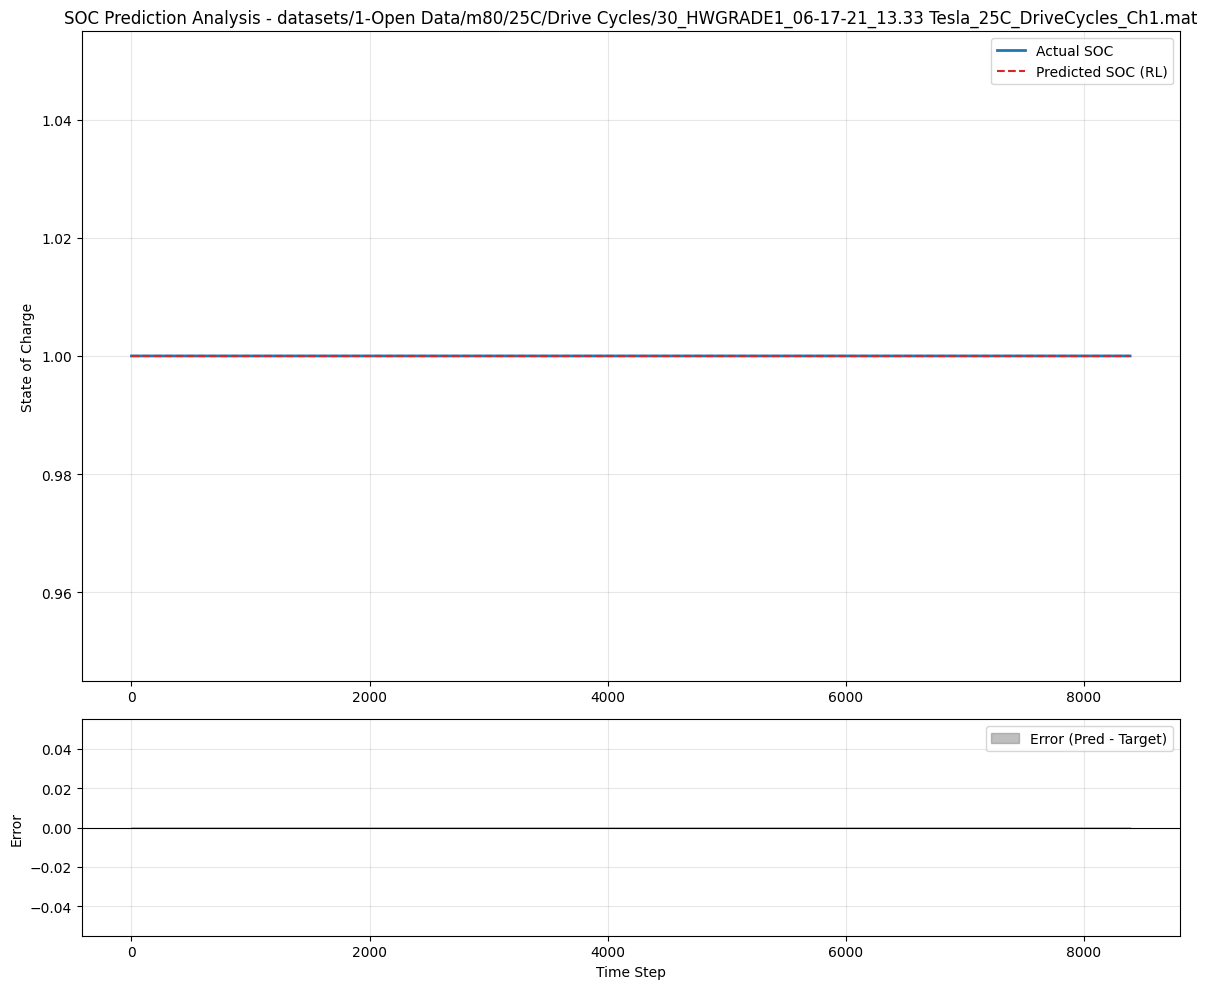

{'mae': np.float64(0.0),
 'rmse': np.float64(0.0),
 'mape': np.float64(0.0),
 'r2': 1.0}

In [13]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3 import DDPG # Ganti PPO ke DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score


env = BatteryEnv(df_train)

n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

model = DDPG(
    "MlpPolicy", 
    env, 
    action_noise=action_noise,
    verbose=1, 
    learning_rate=0.001, # DDPG biasanya butuh LR yang disesuaikan
    buffer_size=100000,   # DDPG menggunakan Replay Buffer
    batch_size=64,
    tau=0.005,            # Soft update coefficient
    gamma=0.99
)

print("Memulai Training...")
model.learn(total_timesteps=100000)
model.save("ddpg_soc_battery")

def evaluate_model(model, df_eval):
    all_sessions = df_eval['Session_ID'].unique()
    random_idx = np.random.randint(0, len(all_sessions))
    
    test_session_id = df_eval['Session_ID'].unique()[random_idx]
    data_test = df_eval[df_eval['Session_ID'] == test_session_id].reset_index(drop=True)
    
    predictions = []
    targets = []
    
    obs = np.array(data_test.iloc[0][features].values, dtype=np.float32)
    
    print(f"INFO: Evaluating Session: {test_session_id} ---")
    
    for i in range(len(data_test)):
        action, _states = model.predict(obs, deterministic=True)
        predictions.append(action[0])
        targets.append(data_test.iloc[i]['SOC'])
        
        if i + 1 < len(data_test):
            obs = np.array(data_test.iloc[i+1][features].values, dtype=np.float32)

    targets = np.array(targets)
    predictions = np.array(predictions)

    mae = np.mean(np.abs(targets - predictions))
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    
    mape = np.mean(np.abs((targets - predictions) / (targets + 1e-10))) * 100

    print(f"MAE   : {mae:.5f}")
    print(f"RMSE  : {rmse:.5f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"R2    : {r2:.5f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(targets, label='Actual SOC', color='#1f77b4', linewidth=2)
    ax1.plot(predictions, label='Predicted SOC (RL)', color='#d62728', linestyle='--')
    ax1.set_title(f'SOC Prediction Analysis - {test_session_id}')
    ax1.set_ylabel('State of Charge')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    error = predictions - targets
    ax2.fill_between(range(len(error)), error, color='gray', alpha=0.5, label='Error (Pred - Target)')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

evaluate_model(model, df_test)

INFO: Evaluating Session: datasets/1-Open Data/m80/25C/Drive Cycles/25_CC_CV_charge_06-16-21_17.14 Tesla_25C_DriveCycles_Ch1.mat ---
MAE   : 0.03163
RMSE  : 0.05697
MAPE  : 14.86%
R2    : 0.96975


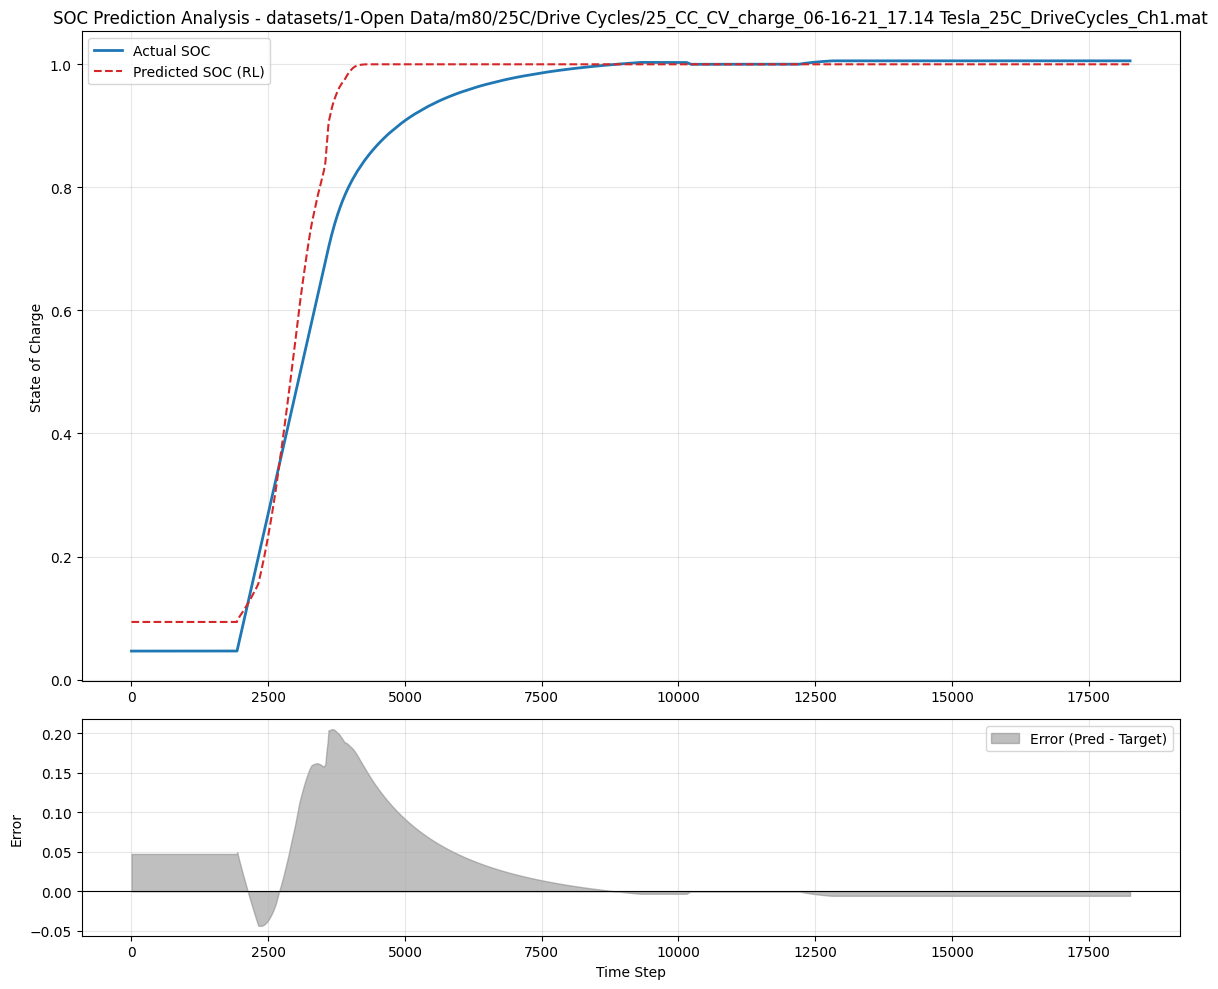

{'mae': np.float64(0.03163058079706688),
 'rmse': np.float64(0.05696941538040296),
 'mape': np.float64(14.858371305083917),
 'r2': 0.9697483990398327}

In [14]:
evaluate_model(model, df_test)

# Twin Delayed Deep Deterministic Policy Gradient

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Memulai Training dengan TD3...
INFO: Evaluating Session: datasets/1-Open Data/m80/10C/Drive Cycles/14_REORDERED3_09-20-21_06.25 Tesla_10C_DriveCycles_Ch1.mat ---
MAE   : 0.00000
RMSE  : 0.00000
MAPE  : 0.00%
R2    : 1.00000


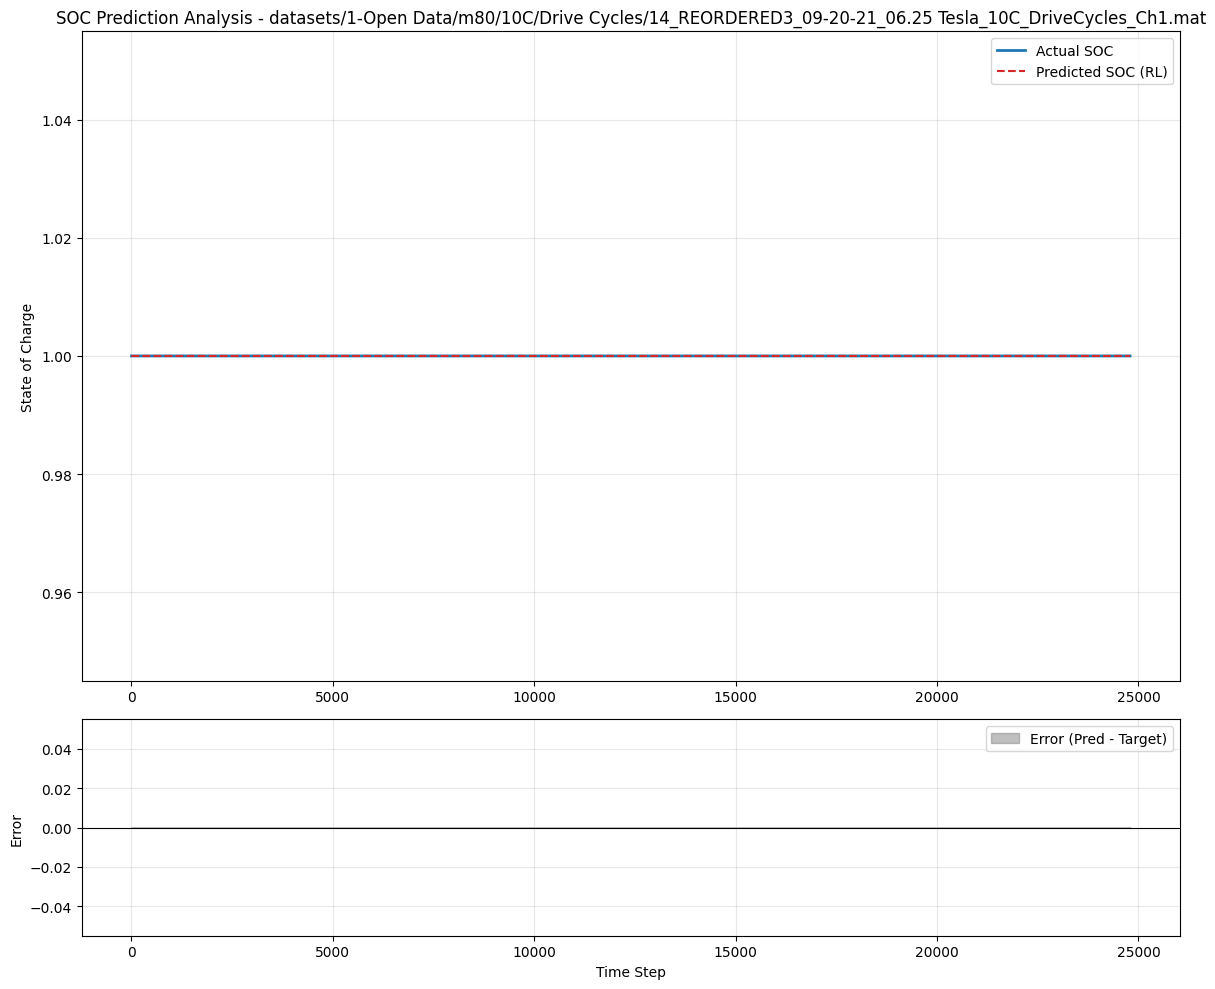

{'mae': np.float64(0.0),
 'rmse': np.float64(0.0),
 'mape': np.float64(0.0),
 'r2': 1.0}

In [15]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3 import DDPG, TD3
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score


env = BatteryEnv(df_train)

n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

model = TD3(
    "MlpPolicy", 
    env, 
    action_noise=action_noise,
    verbose=1, 
    learning_rate=0.001,
    buffer_size=100000,
    batch_size=100,       # TD3 biasanya bekerja baik dengan batch size sedikit lebih besar
    tau=0.005,
    gamma=0.99,
    policy_delay=2,       # Parameter khas TD3: Update policy setiap 2 kali update critic
    target_policy_noise=0.2, # Noise tambahan untuk target smoothing
    target_noise_clip=0.5
)

print("Memulai Training dengan TD3...")
model.learn(total_timesteps=100000)
model.save("td3_soc_battery")

def evaluate_model(model, df_eval):
    all_sessions = df_eval['Session_ID'].unique()
    random_idx = np.random.randint(0, len(all_sessions))
    
    test_session_id = df_eval['Session_ID'].unique()[random_idx]
    data_test = df_eval[df_eval['Session_ID'] == test_session_id].reset_index(drop=True)
    
    predictions = []
    targets = []
    
    obs = np.array(data_test.iloc[0][features].values, dtype=np.float32)
    
    print(f"INFO: Evaluating Session: {test_session_id} ---")
    
    for i in range(len(data_test)):
        action, _states = model.predict(obs, deterministic=True)
        predictions.append(action[0])
        targets.append(data_test.iloc[i]['SOC'])
        
        if i + 1 < len(data_test):
            obs = np.array(data_test.iloc[i+1][features].values, dtype=np.float32)

    targets = np.array(targets)
    predictions = np.array(predictions)

    mae = np.mean(np.abs(targets - predictions))
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    
    mape = np.mean(np.abs((targets - predictions) / (targets + 1e-10))) * 100

    print(f"MAE   : {mae:.5f}")
    print(f"RMSE  : {rmse:.5f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"R2    : {r2:.5f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(targets, label='Actual SOC', color='#1f77b4', linewidth=2)
    ax1.plot(predictions, label='Predicted SOC (RL)', color='#d62728', linestyle='--')
    ax1.set_title(f'SOC Prediction Analysis - {test_session_id}')
    ax1.set_ylabel('State of Charge')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    error = predictions - targets
    ax2.fill_between(range(len(error)), error, color='gray', alpha=0.5, label='Error (Pred - Target)')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

evaluate_model(model, df_test)

# Proximal Policy Optimization

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Memulai Training...
-----------------------------
| time/              |      |
|    fps             | 527  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 719         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.020096274 |
|    clip_fraction        | 0.279       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | 0           |
|    learning_rate        | 0.0003      |
|    loss                 | 0.768       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0309     |
|   

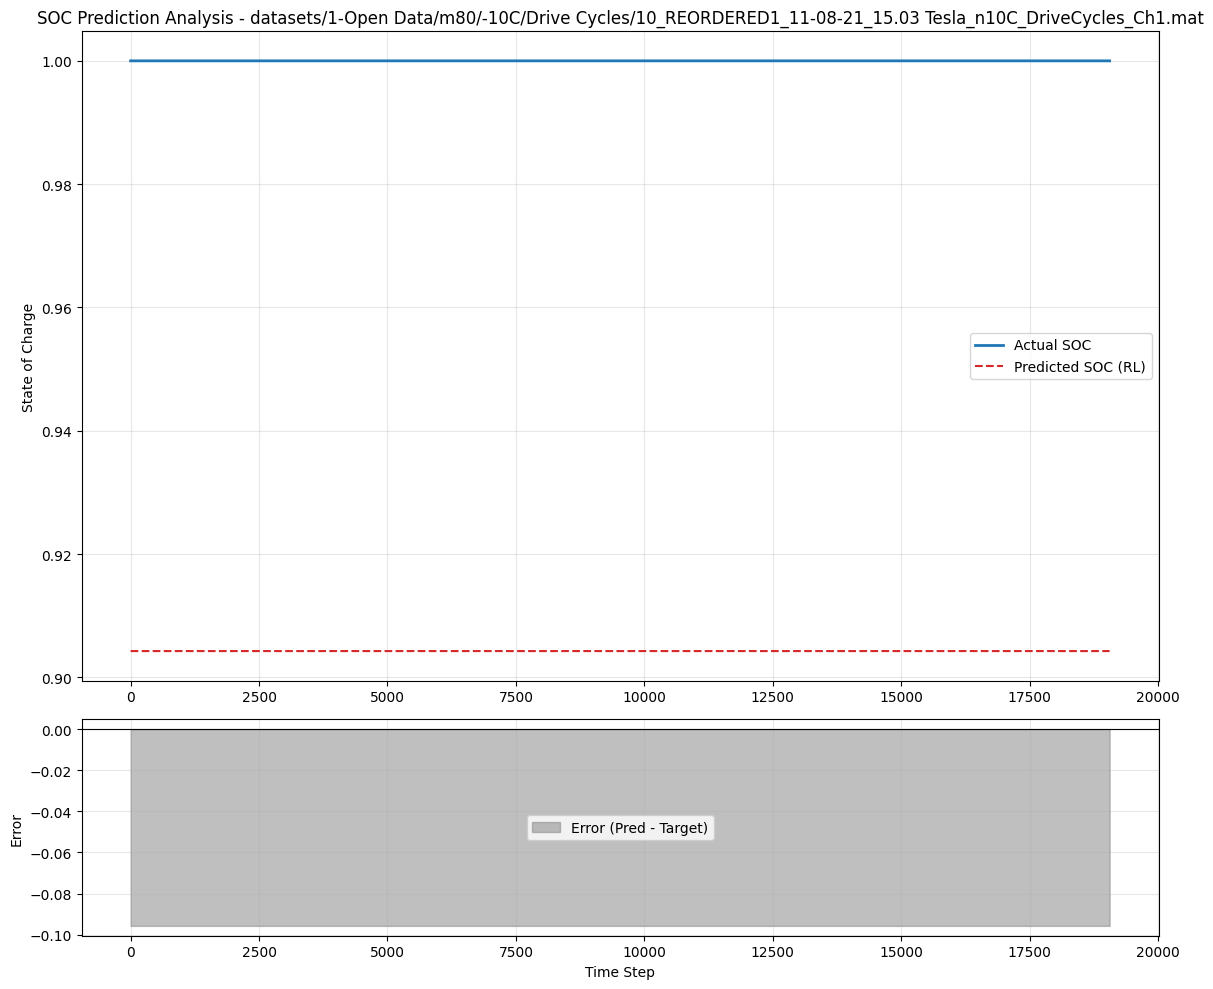

{'mae': np.float64(0.09573477506637573),
 'rmse': np.float64(0.09573477506637573),
 'mape': np.float64(9.573477505680227),
 'r2': 0.0}

In [16]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score


env = BatteryEnv(df_train)

model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003)

print("Memulai Training...")
model.learn(total_timesteps=100000)
model.save("ppo_soc_battery")

def evaluate_model(model, df_eval):
    all_sessions = df_eval['Session_ID'].unique()
    random_idx = np.random.randint(0, len(all_sessions))
    
    test_session_id = df_eval['Session_ID'].unique()[random_idx]
    data_test = df_eval[df_eval['Session_ID'] == test_session_id].reset_index(drop=True)
    
    predictions = []
    targets = []
    
    obs = np.array(data_test.iloc[0][features].values, dtype=np.float32)
    
    print(f"INFO: Evaluating Session: {test_session_id} ---")
    
    for i in range(len(data_test)):
        action, _states = model.predict(obs, deterministic=True)
        predictions.append(action[0])
        targets.append(data_test.iloc[i]['SOC'])
        
        if i + 1 < len(data_test):
            obs = np.array(data_test.iloc[i+1][features].values, dtype=np.float32)

    targets = np.array(targets)
    predictions = np.array(predictions)

    mae = np.mean(np.abs(targets - predictions))
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    
    mape = np.mean(np.abs((targets - predictions) / (targets + 1e-10))) * 100

    print(f"MAE   : {mae:.5f}")
    print(f"RMSE  : {rmse:.5f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"R2    : {r2:.5f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(targets, label='Actual SOC', color='#1f77b4', linewidth=2)
    ax1.plot(predictions, label='Predicted SOC (RL)', color='#d62728', linestyle='--')
    ax1.set_title(f'SOC Prediction Analysis - {test_session_id}')
    ax1.set_ylabel('State of Charge')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    error = predictions - targets
    ax2.fill_between(range(len(error)), error, color='gray', alpha=0.5, label='Error (Pred - Target)')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

evaluate_model(model, df_test)

TRPO

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Memulai Training...
-----------------------------
| time/              |      |
|    fps             | 535  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                     |          |
|    fps                    | 799      |
|    iterations             | 2        |
|    time_elapsed           | 5        |
|    total_timesteps        | 4096     |
| train/                    |          |
|    explained_variance     | 0        |
|    is_line_search_success | 1        |
|    kl_divergence_loss     | 0.00987  |
|    learning_rate          | 0.0003   |
|    n_updates              | 1        |
|    policy_objective       | 0.0377   |
|    std                    | 1.04     |
|    value_loss             | 65.9     |
----------------------------------------
--------------------

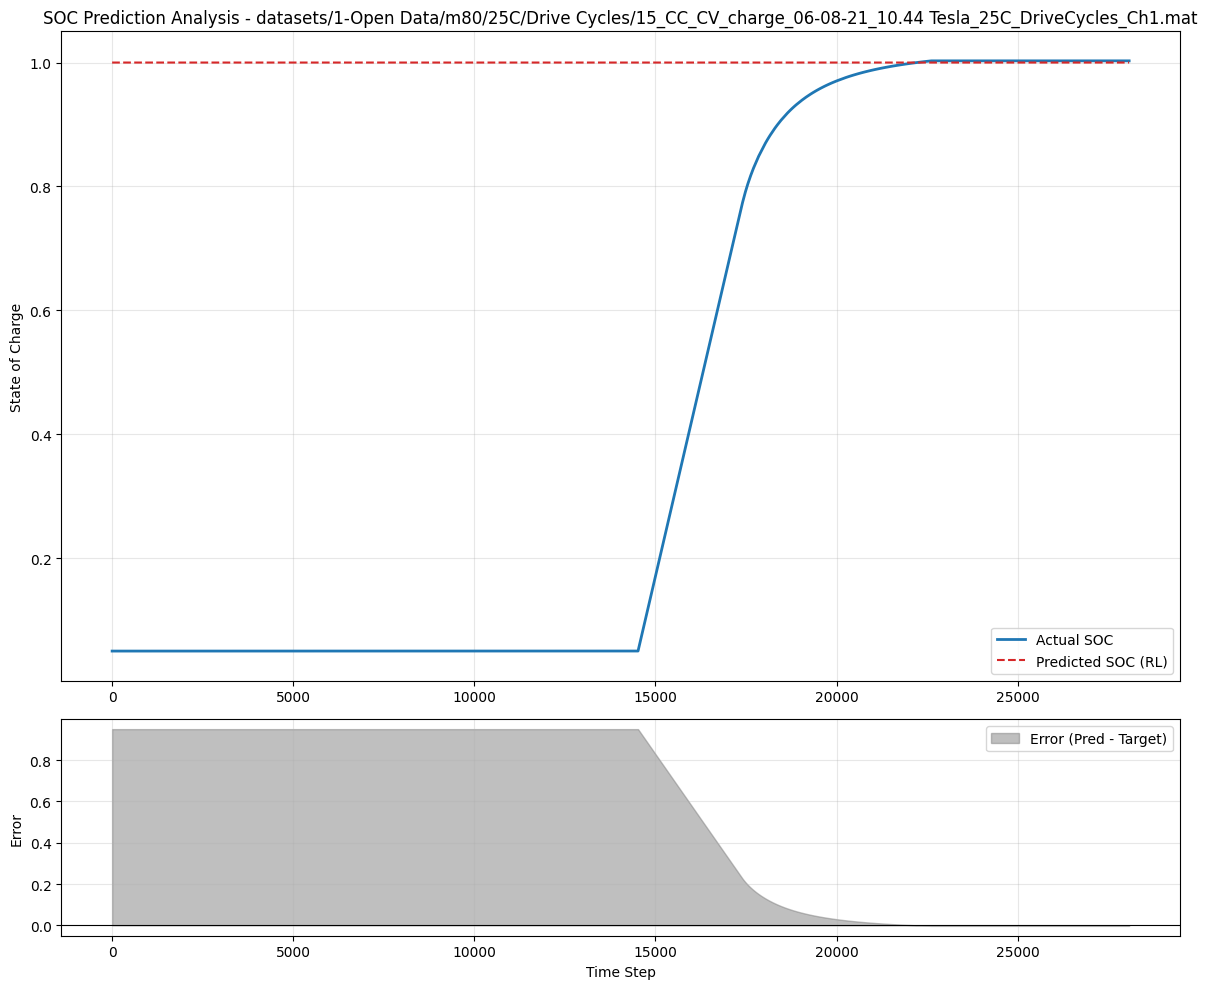

{'mae': np.float64(0.5617293381811357),
 'rmse': np.float64(0.7125397433904802),
 'mape': np.float64(1011.1967846537801),
 'r2': -1.6249838799976826}

In [17]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score
from sb3_contrib import TRPO


env = BatteryEnv(df_train)

model = TRPO("MlpPolicy", env, verbose=1, learning_rate=0.0003)

print("Memulai Training...")
model.learn(total_timesteps=100000)
model.save("trpo_soc_battery")

def evaluate_model(model, df_eval):
    all_sessions = df_eval['Session_ID'].unique()
    random_idx = np.random.randint(0, len(all_sessions))
    
    test_session_id = df_eval['Session_ID'].unique()[random_idx]
    data_test = df_eval[df_eval['Session_ID'] == test_session_id].reset_index(drop=True)
    
    predictions = []
    targets = []
    
    obs = np.array(data_test.iloc[0][features].values, dtype=np.float32)
    
    print(f"INFO: Evaluating Session: {test_session_id} ---")
    
    for i in range(len(data_test)):
        action, _states = model.predict(obs, deterministic=True)
        predictions.append(action[0])
        targets.append(data_test.iloc[i]['SOC'])
        
        if i + 1 < len(data_test):
            obs = np.array(data_test.iloc[i+1][features].values, dtype=np.float32)

    targets = np.array(targets)
    predictions = np.array(predictions)

    mae = np.mean(np.abs(targets - predictions))
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    
    mape = np.mean(np.abs((targets - predictions) / (targets + 1e-10))) * 100

    print(f"MAE   : {mae:.5f}")
    print(f"RMSE  : {rmse:.5f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"R2    : {r2:.5f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(targets, label='Actual SOC', color='#1f77b4', linewidth=2)
    ax1.plot(predictions, label='Predicted SOC (RL)', color='#d62728', linestyle='--')
    ax1.set_title(f'SOC Prediction Analysis - {test_session_id}')
    ax1.set_ylabel('State of Charge')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    error = predictions - targets
    ax2.fill_between(range(len(error)), error, color='gray', alpha=0.5, label='Error (Pred - Target)')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

evaluate_model(model, df_test)